# Benchmark riguroso de inferencia y eficiencia computacional — UNet++

Este notebook mide la velocidad de inferencia, la latencia del posprocesamiento y la escalabilidad por lotes de **UNet++-D5 con encoder ResNet34 y atención SCSE**, en GPU o CPU.

### Metodología
1. **Benchmark en memoria**: se excluyen lectura de disco, decodificación de imágenes y gráficos.
2. **Warm-up**: se descartan 30 iteraciones para estabilizar CUDA, cachés y frecuencia de GPU.
3. **Sincronización estricta**: se usan eventos CUDA y `torch.cuda.synchronize()` en GPU; `time.perf_counter()` en CPU.
4. **Métricas**:
   - media, mediana, desviación estándar, P95, P99, mínimo y máximo;
   - FPS (`1000 / latencia media` para batch 1);
   - FP32 frente a AMP FP16;
   - pipeline GPU: forward + interpolación opcional + sigmoid + umbralización;
   - escalabilidad para `batch size ∈ {1, 2, 4, 8}`.
5. **Salida para IEEE**: genera una fila LaTeX usando las métricas de validación guardadas en el checkpoint.

> El pipeline medido comienza con un tensor ya normalizado y cargado en el dispositivo. No incluye lectura, resize, conversión RGB ni normalización en CPU.

In [1]:
# ==== Configuración para Colab / entorno local ================================
%pip install -q segmentation-models-pytorch

import os
import sys

try:
    from google.colab import drive

    drive.mount('/content/drive', force_remount=False)
    project_path = '/content/drive/MyDrive/tp_computer_vision_ii'
    notebook_dir = os.path.join(project_path, 'src', 'unet')
    os.chdir(notebook_dir)

    if notebook_dir not in sys.path:
        sys.path.insert(0, notebook_dir)

    IN_COLAB = True
    print('Directorio actual en Colab:', os.getcwd())

except ImportError:
    IN_COLAB = False
    current_dir = os.getcwd()
    if current_dir not in sys.path:
        sys.path.insert(0, current_dir)
    print('Ejecutando en entorno local. Directorio actual:', current_dir)

Mounted at /content/drive
Directorio actual en Colab: /content/drive/MyDrive/tp_computer_vision_ii/src/unet


In [2]:
# ==============================================================================
# 1. PARÁMETROS CONFIGURABLES DEL BENCHMARK
# ==============================================================================

CHECKPOINT_PATH = 'best_unet_unet++resnet34_5layers.pth'
VARIANT = 'UNet++-D5-ResNet34'
MODEL_DESCRIPTION = 'UNet++ / ResNet34'
THRESHOLD_FALLBACK = 0.5

INPUT_HEIGHT = 512
INPUT_WIDTH = 512
WARMUP_ITERS = 30
BENCHMARK_ITERS = 150

BATCH_SIZES_TO_TEST = [1, 2, 4, 8]
E2E_USE_AMP = False
BATCH_USE_AMP = False

In [3]:
# ==============================================================================
# 2. IMPORTS, DISPOSITIVO Y RESOLUCIÓN DE RUTAS
# ==============================================================================
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import segmentation_models_pytorch as smp
import torch
import torch.nn.functional as F


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de cómputo : {device}')
if device.type == 'cuda':
    print(f'GPU detectada          : {torch.cuda.get_device_name(0)}')
    print(f'Memoria VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')


def resolve_path(path_str):
    """Busca el checkpoint desde el directorio actual y ubicaciones comunes del proyecto."""
    path = Path(path_str.replace('\\', '/')).expanduser()
    if path.is_absolute() and path.exists():
        return path.resolve()

    roots = [
        Path.cwd(),
        Path.cwd() / 'src' / 'unet',
        Path.cwd().parent / 'unet',
        Path.cwd().parent.parent / 'src' / 'unet',
    ]
    if 'project_path' in globals():
        roots.insert(0, Path(project_path) / 'src' / 'unet')

    for root in roots:
        candidate = root / path
        if candidate.exists():
            return candidate.resolve()

    return path

Dispositivo de cómputo : cuda
GPU detectada          : Tesla T4
Memoria VRAM disponible: 14.56 GB


In [5]:
# ==============================================================================
# 3. CARGA Y PREPARACIÓN DEL MODELO UNET++
# ==============================================================================

def build_unetplusplus():
    """Construye exactamente la arquitectura utilizada durante el entrenamiento."""
    return smp.UnetPlusPlus(
        encoder_name='resnet34',
        encoder_depth=5,
        encoder_weights=None,
        decoder_channels=(512, 256, 128, 64, 32),
        decoder_use_norm='batchnorm',
        decoder_attention_type=None,
        in_channels=3,
        classes=1,
        activation=None,
    )


def load_benchmark_model(checkpoint_path, device):
    resolved_ckpt = resolve_path(checkpoint_path)
    if not resolved_ckpt.exists():
        raise FileNotFoundError(f'No se encontró el checkpoint: {resolved_ckpt}')

    checkpoint = torch.load(resolved_ckpt, map_location='cpu')
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    state_dict = {
        key.removeprefix('module.').removeprefix('model.'): value
        for key, value in state_dict.items()
    }

    model = build_unetplusplus()
    model.load_state_dict(state_dict, strict=True)
    model.to(device).eval()

    threshold = float(checkpoint.get('threshold', THRESHOLD_FALLBACK))
    print(f'Checkpoint cargado: {resolved_ckpt}')
    print(
        f"Época: {checkpoint.get('epoch', 'N/A')} | "
        f"Val mIoU: {checkpoint.get('val_miou', 'N/A')} | "
        f"Val Crack IoU: {checkpoint.get('val_crack_iou', 'N/A')} | "
        f'Umbral: {threshold:.3f}'
    )
    return model, checkpoint, threshold


model, checkpoint, threshold = load_benchmark_model(CHECKPOINT_PATH, device)

total_params = sum(parameter.numel() for parameter in model.parameters())
trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
param_mb = total_params * 4 / 1024**2

print(f'\n--- Complejidad de {VARIANT} ---')
print(f'Parámetros totales     : {total_params / 1e6:.2f} M ({total_params:,})')
print(f'Parámetros entrenables : {trainable_params / 1e6:.2f} M')
print(f'Tamaño de parámetros FP32: {param_mb:.2f} MB')

Checkpoint cargado: /content/drive/MyDrive/tp_computer_vision_ii/src/unet/best_unet_unet++resnet34_5layers.pth
Época: 12 | Val mIoU: 0.8460103869438171 | Val Crack IoU: 0.706630289554596 | Umbral: 0.500

--- Complejidad de UNet++-D5-ResNet34 ---
Parámetros totales     : 31.86 M (31,861,473)
Parámetros entrenables : 31.86 M
Tamaño de parámetros FP32: 121.54 MB


In [6]:
# ==============================================================================
# 4. BENCHMARK: FORWARD PASS PURO (FP32 vs AMP FP16)
# ==============================================================================

dummy_input_single = torch.randn(1, 3, INPUT_HEIGHT, INPUT_WIDTH, device=device)


def run_forward_benchmark(model, input_tensor, device, warmup=30, iters=150, use_amp=False):
    """Mide exclusivamente `model(input_tensor)`."""
    model.eval()
    amp_enabled = use_amp and device.type == 'cuda'

    with torch.inference_mode():
        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            for _ in range(warmup):
                _ = model(input_tensor)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    latencies = []
    with torch.inference_mode():
        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            for _ in range(iters):
                if device.type == 'cuda':
                    start_event = torch.cuda.Event(enable_timing=True)
                    end_event = torch.cuda.Event(enable_timing=True)
                    start_event.record()
                    _ = model(input_tensor)
                    end_event.record()
                    torch.cuda.synchronize()
                    latencies.append(start_event.elapsed_time(end_event))
                else:
                    start = time.perf_counter()
                    _ = model(input_tensor)
                    latencies.append((time.perf_counter() - start) * 1000.0)

    latencies = np.asarray(latencies)
    return {
        'mean': latencies.mean(),
        'median': np.median(latencies),
        'std': latencies.std(),
        'p95': np.percentile(latencies, 95),
        'p99': np.percentile(latencies, 99),
        'min': latencies.min(),
        'max': latencies.max(),
        'fps': 1000.0 / latencies.mean(),
        'raw_latencies': latencies,
    }


print('Ejecutando forward FP32 (BS=1, 512×512)...')
stats_fp32 = run_forward_benchmark(
    model, dummy_input_single, device,
    warmup=WARMUP_ITERS, iters=BENCHMARK_ITERS, use_amp=False,
)
print(f"Media: {stats_fp32['mean']:.2f} ± {stats_fp32['std']:.2f} ms")
print(f"Mediana: {stats_fp32['median']:.2f} ms | P95: {stats_fp32['p95']:.2f} | P99: {stats_fp32['p99']:.2f}")
print(f"Rango: [{stats_fp32['min']:.2f}, {stats_fp32['max']:.2f}] ms | FPS: {stats_fp32['fps']:.2f}")

stats_fp16 = None
if device.type == 'cuda':
    print('\nEjecutando forward AMP FP16...')
    stats_fp16 = run_forward_benchmark(
        model, dummy_input_single, device,
        warmup=WARMUP_ITERS, iters=BENCHMARK_ITERS, use_amp=True,
    )
    print(f"Media: {stats_fp16['mean']:.2f} ± {stats_fp16['std']:.2f} ms")
    print(f"Mediana: {stats_fp16['median']:.2f} ms | P95: {stats_fp16['p95']:.2f} | P99: {stats_fp16['p99']:.2f}")
    print(f"FPS: {stats_fp16['fps']:.2f} | Speedup: {stats_fp32['mean'] / stats_fp16['mean']:.2f}×")

Ejecutando forward FP32 (BS=1, 512×512)...
Media: 44.45 ± 0.46 ms
Mediana: 44.42 ms | P95: 45.28 | P99: 45.60
Rango: [43.45, 45.78] ms | FPS: 22.50

Ejecutando forward AMP FP16...
Media: 27.48 ± 0.68 ms
Mediana: 27.32 ms | P95: 28.46 | P99: 31.04
FPS: 36.39 | Speedup: 1.62×


In [7]:
# ==============================================================================
# 5. BENCHMARK: FORWARD + POSPROCESAMIENTO DE SEGMENTACIÓN BINARIA
# ==============================================================================
# El tensor de entrada ya está en el dispositivo. Se mide:
# UNet++ -> interpolación opcional -> sigmoid -> threshold.


def run_pipeline_e2e_benchmark(
    model, input_tensor, device, threshold=0.5,
    warmup=30, iters=150, use_amp=False,
):
    model.eval()
    amp_enabled = use_amp and device.type == 'cuda'
    output_size = input_tensor.shape[-2:]

    def predict_mask():
        logits = model(input_tensor)
        if logits.shape[-2:] != output_size:
            logits = F.interpolate(
                logits, size=output_size,
                mode='bilinear', align_corners=False,
            )
        return torch.sigmoid(logits) >= threshold

    with torch.inference_mode():
        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            for _ in range(warmup):
                _ = predict_mask()
    if device.type == 'cuda':
        torch.cuda.synchronize()

    latencies = []
    with torch.inference_mode():
        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            for _ in range(iters):
                if device.type == 'cuda':
                    start_event = torch.cuda.Event(enable_timing=True)
                    end_event = torch.cuda.Event(enable_timing=True)
                    start_event.record()
                    _ = predict_mask()
                    end_event.record()
                    torch.cuda.synchronize()
                    latencies.append(start_event.elapsed_time(end_event))
                else:
                    start = time.perf_counter()
                    _ = predict_mask()
                    latencies.append((time.perf_counter() - start) * 1000.0)

    latencies = np.asarray(latencies)
    return {
        'mean': latencies.mean(),
        'median': np.median(latencies),
        'std': latencies.std(),
        'p95': np.percentile(latencies, 95),
        'p99': np.percentile(latencies, 99),
        'fps': 1000.0 / latencies.mean(),
        'raw_latencies': latencies,
    }


precision_e2e = 'AMP FP16' if E2E_USE_AMP and device.type == 'cuda' else 'FP32'
print(f'Ejecutando pipeline GPU ({precision_e2e}, BS=1, 512×512)...')
stats_e2e = run_pipeline_e2e_benchmark(
    model, dummy_input_single, device, threshold=threshold,
    warmup=WARMUP_ITERS, iters=BENCHMARK_ITERS,
    use_amp=E2E_USE_AMP,
)
print(f"Media: {stats_e2e['mean']:.2f} ± {stats_e2e['std']:.2f} ms")
print(f"Mediana: {stats_e2e['median']:.2f} ms | P95: {stats_e2e['p95']:.2f} | P99: {stats_e2e['p99']:.2f}")
print(f"Throughput: {stats_e2e['fps']:.2f} FPS")

Ejecutando pipeline GPU (FP32, BS=1, 512×512)...
Media: 45.24 ± 0.56 ms
Mediana: 45.18 ms | P95: 46.05 | P99: 46.58
Throughput: 22.10 FPS


In [8]:
# ==============================================================================
# 6. ESCALABILIDAD POR TAMAÑO DE LOTE
# ==============================================================================

batch_results = []
batch_precision = 'AMP FP16' if BATCH_USE_AMP and device.type == 'cuda' else 'FP32'
print(f'Precisión del benchmark por lotes: {batch_precision}')
print(f"{'Batch Size':<12} | {'Latencia batch (ms)':<22} | {'Latencia/imagen (ms)':<24} | {'Throughput (FPS)':<18}")
print('-' * 84)

for batch_size in BATCH_SIZES_TO_TEST:
    try:
        input_batch = torch.randn(
            batch_size, 3, INPUT_HEIGHT, INPUT_WIDTH,
            device=device,
        )
        stats_batch = run_forward_benchmark(
            model, input_batch, device,
            warmup=15, iters=50,
            use_amp=BATCH_USE_AMP,
        )

        batch_latency = stats_batch['mean']
        per_image_latency = batch_latency / batch_size
        throughput = batch_size * 1000.0 / batch_latency

        batch_results.append({
            'batch_size': batch_size,
            'batch_latency_ms': batch_latency,
            'per_img_latency_ms': per_image_latency,
            'fps': throughput,
        })
        print(f'{batch_size:<12} | {batch_latency:<22.2f} | {per_image_latency:<24.2f} | {throughput:<18.2f}')

        del input_batch, stats_batch
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    except torch.cuda.OutOfMemoryError:
        print(f'{batch_size:<12} | OOM: el lote no cabe en la GPU; se detiene el escalado.')
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        break

Precisión del benchmark por lotes: FP32
Batch Size   | Latencia batch (ms)    | Latencia/imagen (ms)     | Throughput (FPS)  
------------------------------------------------------------------------------------
1            | 45.52                  | 45.52                    | 21.97             
2            | 89.92                  | 44.96                    | 22.24             
4            | 181.17                 | 45.29                    | 22.08             
8            | 371.54                 | 46.44                    | 21.53             


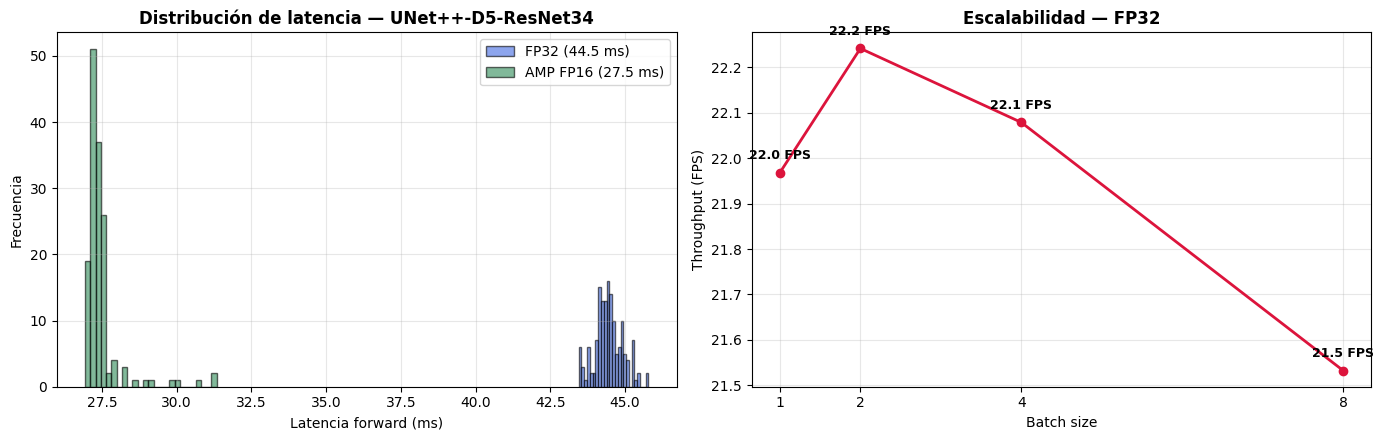

RESUMEN CONSOLIDADO DE EFICIENCIA
Arquitectura            : UNet++-D5-ResNet34
Parámetros totales      : 31.86 M (121.5 MB en FP32)
Dispositivo             : cuda (Tesla T4)
Forward FP32            : 44.45 ms (22.50 FPS)
Forward AMP FP16        : 27.48 ms (36.39 FPS)
Modo forward más rápido : AMP FP16
Pipeline FP32       : 45.24 ms (22.10 FPS)

Métricas tomadas del conjunto de validación guardado en el checkpoint.
Sustituirlas por métricas de test si la Tabla II reporta el conjunto de prueba.

FILA PARA LA TABLA II EN main.tex
\textbf{UNet++-D5-ResNet34} & UNet++ / ResNet34 & 0.8460 & 0.7066 & 0.8754 & 0.7857 & 0.8281 & \textbf{27.48} & \textbf{36.39} \\


In [9]:
# ==============================================================================
# 7. GRÁFICOS Y FILA PARA TABLA IEEE
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(
    stats_fp32['raw_latencies'], bins=25, alpha=0.6,
    color='royalblue', edgecolor='black',
    label=f"FP32 ({stats_fp32['mean']:.1f} ms)",
)
if stats_fp16 is not None:
    axes[0].hist(
        stats_fp16['raw_latencies'], bins=25, alpha=0.6,
        color='seagreen', edgecolor='black',
        label=f"AMP FP16 ({stats_fp16['mean']:.1f} ms)",
    )
axes[0].set_xlabel('Latencia forward (ms)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'Distribución de latencia — {VARIANT}', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

batch_sizes = [result['batch_size'] for result in batch_results]
batch_fps = [result['fps'] for result in batch_results]
axes[1].plot(batch_sizes, batch_fps, marker='o', color='crimson', lw=2)
axes[1].set_xlabel('Batch size')
axes[1].set_ylabel('Throughput (FPS)')
axes[1].set_title(f'Escalabilidad — {batch_precision}', fontweight='bold')
axes[1].set_xticks(batch_sizes)
axes[1].grid(True, alpha=0.3)
for x_value, y_value in zip(batch_sizes, batch_fps):
    axes[1].annotate(
        f'{y_value:.1f} FPS', (x_value, y_value),
        textcoords='offset points', xytext=(0, 10), ha='center',
        fontweight='bold', fontsize=9,
    )

plt.tight_layout()
plt.show()

forward_candidates = [('FP32', stats_fp32)]
if stats_fp16 is not None:
    forward_candidates.append(('AMP FP16', stats_fp16))
best_precision, best_forward = min(
    forward_candidates,
    key=lambda candidate: candidate[1]['mean'],
)

val_miou = float(checkpoint.get('val_miou', np.nan))
val_crack_iou = float(checkpoint.get('val_crack_iou', np.nan))
val_precision = float(checkpoint.get('val_precision', np.nan))
val_recall = float(checkpoint.get('val_recall', np.nan))
val_f1 = float(checkpoint.get('val_f1', np.nan))

print('=' * 80)
print('RESUMEN CONSOLIDADO DE EFICIENCIA')
print('=' * 80)
print(f'Arquitectura            : {VARIANT}')
print(f'Parámetros totales      : {total_params / 1e6:.2f} M ({param_mb:.1f} MB en FP32)')
print(f'Dispositivo             : {device} ({torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU"})')
print(f'Forward FP32            : {stats_fp32["mean"]:.2f} ms ({stats_fp32["fps"]:.2f} FPS)')
if stats_fp16 is not None:
    print(f'Forward AMP FP16        : {stats_fp16["mean"]:.2f} ms ({stats_fp16["fps"]:.2f} FPS)')
print(f'Modo forward más rápido : {best_precision}')
print(f'Pipeline {precision_e2e:<10} : {stats_e2e["mean"]:.2f} ms ({stats_e2e["fps"]:.2f} FPS)')
print('=' * 80)

print('\nMétricas tomadas del conjunto de validación guardado en el checkpoint.')
print('Sustituirlas por métricas de test si la Tabla II reporta el conjunto de prueba.')
latex_row = (
    f'\\textbf{{{VARIANT}}} & {MODEL_DESCRIPTION} & '
    f'{val_miou:.4f} & {val_crack_iou:.4f} & '
    f'{val_precision:.4f} & {val_recall:.4f} & {val_f1:.4f} & '
    f'\\textbf{{{best_forward["mean"]:.2f}}} & '
    f'\\textbf{{{best_forward["fps"]:.2f}}} \\\\'
)
print('\nFILA PARA LA TABLA II EN main.tex')
print(latex_row)